# Funnel configuration evaluation

**What this measures.** One real sweep, replayed through eight ranking
configurations, stopping exactly where LLM scoring would begin. For each config it
writes out the jobs that *would* have been handed to the scorer, plus what that
config cost in wall-clock time.

**What this does not measure.** There is no ground truth. The target run was
scraped with `skip_llm: true`, so no job in it ever received an LLM score, and only
756 genuine LLM scores exist in the entire 11.3 GB database. So the question here
is comparative — *does the cheap cascade pick the same jobs the expensive model
would have, and what does the difference cost?* — not "which config is accurate".

**Run**: `2026-07-21T17-43-52Z`, the largest in the database at 20,722 jobs,
restricted to the 13,281 with real descriptions. The 7,441 title-only
Workday/BambooHR rows cannot be hydrated offline, and dropping them is also
faithful to the plugin's defaults, where those two board types ship disabled.

### The eight configurations

| # | Name | Wide | Refine | Gate | Dedupe |
|---|---|---|---|---|---|
| 1 | `original-minilm` | — | — | 0.35 | off |
| 1b | `minilm-controlled` | — | — | 0.25 | on |
| 2 | `cascade-17m-68m` — **the shipped config** | 17m | 68m @500 | 0.25 | on |
| 3 | `direct-68m` | 68m | — | 0.25 | on |
| 4 | `direct-32m` | 32m | — | 0.25 | on |
| 5 | `cascade-17m-32m` | 17m | 32m @500 | 0.25 | on |
| 6 | `cascade-32m-68m` | 32m | 68m @500 | 0.25 | on |
| 7 | `direct-17m` | 17m | — | 0.25 | on |

Config 1 is a **reconstruction, not a replay**. The original HireShire has no
reranker and no top-k at all: `funnel/relevance.py` computes the MiniLM cosine,
compares it to 0.35, and throws the float away. Nothing is ever ranked before LLM
scoring. Config 1 ranks by the number the original discarded, so it can be compared
at all. It also differs from configs 2–7 on three axes at once (title-only ranking,
a higher gate, no clustering), which makes any direct agreement number against it
uninterpretable as reranker quality — hence **config 1b**, which changes only the
ranking signal and holds the pool and clustering fixed. 1b is the honest answer to
"is the cross-encoder earning its keep at all?"

**A shared budget, not a shared threshold.** Every config selects `top_k = 100`.
Cross-encoder logits from different models are on different, uncalibrated scales —
`RerankScores` says so in terms — so a single raw cutoff would mean something
different in every row of that table. A shared *budget* is both comparable and
exactly how `top_k` gates the real pipeline.

## 0. Environment

Two assertions that are worth more than they look. This project has already shipped
a reranker that failed silently for a whole run, and both failure modes below are
silent by nature:

1. **Wrong `transformers`.** The Ettin checkpoints are module-list CrossEncoders
   whose scoring head lives in `2_Dense`/`4_Dense`. Under `transformers < 5` the
   loader falls back to `ModernBertForSequenceClassification` and **randomly
   initializes the head** — every score would be noise, with only a warning to say
   so. The sanity check below catches this by asserting a matching job outscores an
   obviously irrelevant one.
2. **fp32 on a 6 GB card.** Windows WDDM does not raise `CUDA out of memory`, it
   spills to host memory and runs 10–30× slower, which would silently corrupt every
   timing in this notebook. We run fp16 with a small batch and assert on peak VRAM.

In [1]:
import os
# Must precede the first transformers import, or every cell pays the TF import.
os.environ.setdefault("USE_TF", "0")
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")

import importlib.util
import sys

import torch
import transformers
import sentence_transformers

assert torch.cuda.is_available(), "No CUDA device — see analysis/README.md for the venv setup"
assert int(transformers.__version__.split(".")[0]) >= 5, (
    f"transformers {transformers.__version__} cannot load the Ettin rerankers "
    "and will randomly initialize the scoring head"
)
assert importlib.util.find_spec("sentence_transformers.base") is not None, (
    "sentence_transformers is too old for the module-list CrossEncoder layout"
)

_props = torch.cuda.get_device_properties(0)
print(f"python                {sys.version.split()[0]}")
print(f"torch                 {torch.__version__}")
print(f"transformers          {transformers.__version__}")
print(f"sentence-transformers {sentence_transformers.__version__}")
print(f"device                {_props.name}  ({_props.total_memory / 1024**2:.0f} MiB)")

C:\Users\atrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


python                3.12.3
torch                 2.5.1+cu118
transformers          5.15.0
sentence-transformers 5.7.0
device                NVIDIA GeForce RTX 3060 Laptop GPU  (6144 MiB)


## 1. Configuration

In [2]:
import hashlib
import json
import pickle
import re
import sqlite3
import time
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd

PLUGIN_ROOT = Path(r"D:\Atreya\College\Projects\HireShire-plugin")
ORIGINAL_ROOT = Path(r"D:\Atreya\College\Projects\HireShire")
DB_PATH = ORIGINAL_ROOT / "data" / "hireshire.db"
RUN_ID = "2026-07-21T17-43-52Z"

ANALYSIS_DIR = PLUGIN_ROOT / "analysis"
RESULTS_DIR = ANALYSIS_DIR / "results"
CACHE_DIR = ANALYSIS_DIR / "cache"
PROFILE_PATH = ANALYSIS_DIR / "search_profile_swe.md"
for d in (RESULTS_DIR, CACHE_DIR, CACHE_DIR / "scores"):
    d.mkdir(parents=True, exist_ok=True)

# --- experiment knobs -------------------------------------------------------
DESCRIPTIONS_ONLY = True   # see the note below
# int -> deterministic smoke subsample; None -> full run. FUNNEL_SAMPLE_N lets a
# headless `nbconvert --execute` do the smoke pass without editing this cell.
SAMPLE_N = int(os.environ["FUNNEL_SAMPLE_N"]) if os.environ.get("FUNNEL_SAMPLE_N") else None
TOP_K = 100                # the shared budget, in CLUSTERS (matcher.py:_spend_budget)
REFINE_DEPTH = 500         # plugin default; validated by the depth sweep in §7
GATE_PLUGIN = 0.25         # plugin encoder threshold
GATE_ORIGINAL = 0.35       # original repo encoder threshold

# --- reranker knobs (plugin defaults, except dtype/batch) -------------------
MAX_DOC_CHARS = 15_000
MAX_LENGTH = 4096
BATCH_SIZE = 8             # NOT the plugin's 16 — see the fp32/VRAM note above
DTYPE = torch.float16
FORCE_RETIME = False       # re-measure timings without discarding cached scores

print(f"corpus            run {RUN_ID}")
print(f"descriptions only {DESCRIPTIONS_ONLY}")
print(f"budget            top_k={TOP_K} clusters, refine depth={REFINE_DEPTH}")
print(f"reranker          batch={BATCH_SIZE} dtype={DTYPE} max_len={MAX_LENGTH}")
if SAMPLE_N:
    print(f"\n!! SAMPLE_N={SAMPLE_N} — plumbing only. With a pool this small, "
          f"top_k={TOP_K} selects a large fraction of it and every agreement "
          "metric inflates. Set SAMPLE_N=None for real numbers.")

corpus            run 2026-07-21T17-43-52Z
descriptions only True
budget            top_k=100 clusters, refine depth=500
reranker          batch=8 dtype=torch.float16 max_len=4096


**On `DESCRIPTIONS_ONLY`.** With it `True` the pool is 6,267 jobs and every
cross-encoder reads a real description — the job it is actually being asked to do.
With it `False` a further ~3,300 title-only jobs enter, where `Reranker._doc()`
degenerates to the bare title; each model is then scoring a five-word document, and
the experiment mostly measures how each one handles degenerate input. The pool hash
feeds the score cache, so flipping this invalidates the right things automatically.

In [3]:
sys.path.insert(0, str(PLUGIN_ROOT))

# Leaf modules only. `hireshire.paths`, `hireshire.storage.db` and
# `hireshire.matcher.config` resolve plugin DATA directories on import, which in a
# notebook would point at the live install rather than at this analysis.
from hireshire.funnel import cluster
from hireshire.funnel.config import RerankConfig, RerankRefineConfig
from hireshire.funnel.rerank import RerankScores, Reranker
from hireshire.models.job import Job

for m in (cluster, Job.__module__):
    pass
print("cluster  ", cluster.__file__)
print("rerank   ", Reranker.__module__, sys.modules[Reranker.__module__].__file__)

def sha(*parts) -> str:
    h = hashlib.sha256()
    for p in parts:
        h.update(str(p).encode("utf-8", "replace"))
    return h.hexdigest()[:16]

# Any edit to the ranking code must invalidate cached scores.
CODE_SHA = sha(
    (PLUGIN_ROOT / "hireshire/funnel/rerank.py").read_text(encoding="utf-8"),
    (PLUGIN_ROOT / "hireshire/funnel/cluster.py").read_text(encoding="utf-8"),
)
print("code sha ", CODE_SHA)

cluster   D:\Atreya\College\Projects\HireShire-plugin\hireshire\funnel\cluster.py
rerank    hireshire.funnel.rerank D:\Atreya\College\Projects\HireShire-plugin\hireshire\funnel\rerank.py
code sha  4a866f4fc9b8b9a0


## 2. The reranker query

The cross-encoder's query is not the resume. It is the expanded "ideal candidate"
search profile that `/hireshire:setup` generates — prose that states transferable
skills in the vocabulary employers use, which is what closes the gap when a good job
is worded nothing like the resume. `matcher.py:_load_search_profile` is emphatic
that this text is *only* ever the reranker's query and never reaches the scorer.

The live `profile.md` in the plugin's data directory describes a B2B account
management persona — a different test user. This run's jobs were scraped against a
software/ML engineering hunt, so `search_profile_swe.md` was generated from
`Udayan_Resume.pdf` for this analysis, mirroring the setup skill's instructions
(`skills/setup/SKILL.md`): a dense ~230-word profile, two prose paragraphs, no
bullets, describing the underlying transferable skills rather than the literal nouns
on the resume.

In [4]:
assert PROFILE_PATH.exists(), f"missing {PROFILE_PATH}"
PROFILE = PROFILE_PATH.read_text(encoding="utf-8").strip()
PROFILE_SHA = sha(PROFILE)
assert 1_000 <= len(PROFILE) <= 2_500, f"profile is {len(PROFILE)} chars — check it"
print(f"{len(PROFILE)} chars, sha {PROFILE_SHA}\n")
print(PROFILE)

1503 chars, sha c1a77e7a5218a295

Early-career software engineer with roughly four years of backend and cloud
engineering experience plus a Master's in Computer Science, now targeting machine
learning, applied AI and AI/LLM engineering roles. Builds and ships production
services end to end: distributed microservice architecture, REST and event-driven
API design, serverless compute, data modelling and schema design, CI/CD pipelines,
observability and performance tuning. Hands-on with AWS (Lambda, API Gateway, S3,
DynamoDB, EventBridge), Azure DevOps, MongoDB and vector databases, and has
measurably reduced retrieval latency, mean time to resolution and operational
overhead on real systems.

Strong applied-AI and LLM engineering depth: retrieval-augmented generation,
agentic and multi-step LLM workflows, semantic search and embedding models,
vector indexing and chunking strategy, prompt engineering, model evaluation and
LLM-as-a-judge benchmarking, hallucination reduction, and latency-ve

## 3. Corpus

The source database belongs to the original HireShire repo, is 11.3 GB, and is
irreplaceable. It is opened read-only and that is *proved* rather than assumed
before any real query runs.

In [5]:
def open_ro() -> sqlite3.Connection:
    con = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)
    con.execute("PRAGMA query_only=ON")
    return con

# Prove the connection cannot write before touching the real data.
_con = open_ro()
try:
    _con.execute("CREATE TABLE _write_probe (x)")
    raise AssertionError("connection is WRITABLE — refusing to continue")
except sqlite3.OperationalError as e:
    print(f"read-only confirmed ({e})")
_con.close()

read-only confirmed (attempt to write a readonly database)


In [6]:
CORPUS_CACHE = CACHE_DIR / f"corpus_{RUN_ID}.pkl"

def load_corpus() -> list[Job]:
    """Rebuild Job objects exactly as the production DatabaseStore does.

    This matters more than it looks: 95.5% of `content_text` in this database is
    raw HTML, and `Job.strip_html` is what turns it into the text the reranker
    actually reads in production. Scoring the raw HTML would be a different
    experiment.
    """
    if CORPUS_CACHE.exists():
        jobs = pickle.loads(CORPUS_CACHE.read_bytes())
        print(f"corpus from cache: {len(jobs):,} jobs")
        return jobs

    con = open_ro()
    # ORDER BY job_id for determinism: 2,279 rows tie on the (board_token, title,
    # updated_at) key that pick_representative breaks ties on, so without a stable
    # order the DB row order would silently decide the cluster representative.
    rows = con.execute(
        "SELECT job_id, raw_json, content_text FROM jobs WHERE run_id = ? ORDER BY job_id",
        (RUN_ID,),
    ).fetchall()
    con.close()
    print(f"{len(rows):,} rows read")

    jobs, skipped = [], 0
    t0 = time.perf_counter()
    for job_id, raw_json, content_text in rows:
        try:
            payload = json.loads(raw_json)
            payload["content_text"] = content_text  # triggers Job.strip_html
            jobs.append(Job(**payload))
        except Exception:
            skipped += 1
    print(f"built {len(jobs):,} Job objects in {time.perf_counter() - t0:.1f}s "
          f"({skipped} skipped)")
    assert skipped / max(len(rows), 1) < 0.005, f"{skipped} rows failed to parse"
    CORPUS_CACHE.write_bytes(pickle.dumps(jobs))
    return jobs

JOBS = load_corpus()
assert len(JOBS) > 20_000, "expected the full run"

corpus from cache: 20,722 jobs


In [7]:
_lens = pd.Series([len(j.content_text or "") for j in JOBS])
_with = _lens[_lens > 0]
print(f"jobs                     {len(JOBS):,}")
print(f"with description         {len(_with):,} ({100 * len(_with) / len(JOBS):.1f}%)")
print(f"description chars        mean {_with.mean():,.0f}   median {_with.median():,.0f}   "
      f"p99 {_with.quantile(0.99):,.0f}   max {_with.max():,.0f}")
print(f"over max_doc_chars       {(_with > MAX_DOC_CHARS).sum()} "
      f"({100 * (_with > MAX_DOC_CHARS).mean():.2f}%)")
print(f"\nby source:")
print(pd.DataFrame({
    "jobs": pd.Series([j.source for j in JOBS]).value_counts(),
    "with_desc": pd.Series([j.source for j in JOBS if j.content_text]).value_counts(),
}).fillna(0).astype(int).to_string())

jobs                     20,722
with description         13,281 (64.1%)
description chars        mean 6,163   median 5,934   p99 11,275   max 20,503
over max_doc_chars       9 (0.07%)

by source:
             jobs  with_desc
ashby         224        224
bamboohr      315          2
greenhouse  12681      12681
lever          64         63
workday      7438        311


Note what the length distribution says about two settings the plugin exposes as
dials: after HTML stripping almost nothing exceeds `max_doc_chars = 15000`, and the
longest pair is well inside `max_length = 4096` tokens. **On this corpus both are
inert.** They are kept at their production values for parity, but no result below
turns on them.

## 4. Funnel replay — the cheap gates

Stages 1–3 of `hireshire/funnel/funnel.py`, in its order: exclude keywords drop,
include keywords fast-pass (kept unconditionally, scored but **not** gated), and the
MiniLM bi-encoder over whatever is left. Everything here sees the **title only**.

The keyword lists and the encoder targets come from the original repo's
`config/matcher.yaml`, because that is the persona this run was scraped for.

In [8]:
INCLUDE_KEYWORDS = [
    "engineer", "developer", "software", "backend", "ml", "machine learning",
    "analyst", "scientist", "gtm", "forward deployed", "ai",
    "artificial intelligence", "go-to market", "go to market",
    "solution architect", "genai", "gen ai", "applied ai", "ai engineer", "swe",
]
EXCLUDE_KEYWORDS = [
    "principle", "staff", "manager", "vp", "director", "principal", "ios", "lead",
    "android", "mobile", "senior", "fullstack", "coop", "co-op", "sr.", "sr",
]
TARGETS = [
    "software engineer", "backend engineer", "machine learning engineer",
    "ai engineer", "ml engineer", "ml/ai engineer", "data scientist",
    "applied ai", "full stack developer", "solutions architect",
    "forward deployed engineer",
]

excluded, fast_passed, candidates = [], [], []
for job in JOBS:
    t = job.title.lower()
    if any(k in t for k in EXCLUDE_KEYWORDS):
        excluded.append(job)
    elif any(k in t for k in INCLUDE_KEYWORDS):
        fast_passed.append(job)
    else:
        candidates.append(job)

print(f"1. exclude keywords drop   {len(excluded):>6,}")
print(f"2. include fast-pass       {len(fast_passed):>6,}   (never gated on the encoder)")
print(f"3. to the encoder          {len(candidates):>6,}")

1. exclude keywords drop    8,956
2. include fast-pass        4,027   (never gated on the encoder)
3. to the encoder           7,739


In [9]:
from sentence_transformers import SentenceTransformer

ENC_CACHE = CACHE_DIR / f"minilm_{RUN_ID}.npz"

def encoder_scores() -> tuple[dict[str, float], float]:
    """Max-over-targets cosine per title, mirroring funnel/relevance.py."""
    if ENC_CACHE.exists():
        d = np.load(ENC_CACHE, allow_pickle=True)
        return dict(zip(d["job_id"].tolist(), d["score"].tolist())), float(d["seconds"])

    model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device="cuda")
    titles = [j.title for j in JOBS]
    t0 = time.perf_counter()
    tgt = model.encode(TARGETS, normalize_embeddings=True, convert_to_numpy=True)
    emb = model.encode(titles, normalize_embeddings=True, convert_to_numpy=True,
                       batch_size=256, show_progress_bar=False)
    scores = (emb @ tgt.T).max(axis=1)   # relevance.py:57-58
    seconds = time.perf_counter() - t0
    ids = np.array([j.job_id for j in JOBS], dtype=object)
    np.savez(ENC_CACHE, job_id=ids, score=scores, seconds=seconds)
    del model
    torch.cuda.empty_cache()
    return dict(zip(ids.tolist(), scores.tolist())), seconds

ENCODER_SCORE, GATE_SECONDS = encoder_scores()
print(f"MiniLM encoded {len(ENCODER_SCORE):,} titles in {GATE_SECONDS:.1f}s")

MiniLM encoded 20,722 titles in 9.4s


In [10]:
def build_pool(threshold: float) -> list[Job]:
    """Fast-passed jobs plus encoder survivors, mirroring funnel.py:74-92."""
    pool = list(fast_passed)
    pool += [j for j in candidates if ENCODER_SCORE[j.job_id] >= threshold]
    if DESCRIPTIONS_ONLY:
        pool = [j for j in pool if j.content_text]
    pool.sort(key=lambda j: j.job_id)          # determinism
    return pool

POOL_PLUGIN = build_pool(GATE_PLUGIN)          # configs 1b, 2-7
if SAMPLE_N:
    POOL_PLUGIN = POOL_PLUGIN[:SAMPLE_N]
# Derived from the plugin pool rather than built independently, so the subset
# relation below holds under sampling too. With SAMPLE_N unset this is a no-op:
# a higher threshold can only ever remove jobs.
_plugin_ids = {j.job_id for j in POOL_PLUGIN}
POOL_ORIGINAL = [j for j in build_pool(GATE_ORIGINAL) if j.job_id in _plugin_ids]

rows = []
for name, thr in (("original (0.35)", GATE_ORIGINAL), ("plugin (0.25)", GATE_PLUGIN)):
    passes = sum(1 for j in candidates if ENCODER_SCORE[j.job_id] >= thr)
    pool = build_pool(thr)
    rows.append({"gate": name, "encoder_passes": passes,
                 "pool_all": len(fast_passed) + passes, "pool_used": len(pool)})
print(pd.DataFrame(rows).to_string(index=False))

assert set(j.job_id for j in POOL_ORIGINAL) <= set(j.job_id for j in POOL_PLUGIN), \
    "the 0.35 pool must be a subset of the 0.25 pool"
POOL_SHA = sha(CODE_SHA, PROFILE_SHA, DESCRIPTIONS_ONLY, SAMPLE_N,
               "|".join(j.job_id for j in POOL_PLUGIN))
print(f"\npool sha {POOL_SHA}")

           gate  encoder_passes  pool_all  pool_used
original (0.35)            2491      6518       4613
  plugin (0.25)            5514      9541       6267

pool sha 6d9d90f4bc966fae


Two things worth reading off that table before going further.

The include fast-pass admits a large block of jobs **without ever consulting the
encoder**, so the 0.35-vs-0.25 difference only ever touches the gated remainder —
the gate is a much weaker lever than its name suggests. And the encoder threshold
is deliberately loose because it is a recall net, not a verdict; the precision
decision is the cross-encoder, which is what everything below is about.

## 5. Scoring engine

Every cross-encoder pass goes through the plugin's own `Reranker._predict`, which
builds the `(profile, "TITLE\n\n" + description)` pair with the production
`_doc()`. The only thing this notebook substitutes is the loaded model object,
pre-seeded into `rerank._MODEL_CACHE` as fp16-on-CUDA. That keeps pair
construction, truncation and prediction identical to production while making the
run fast enough to sweep.

Scores are cached to disk keyed on everything that could change them. Timings are
recorded **only on a cache miss**, so re-running the notebook is instant while the
reported cost stays a real measurement.

In [ ]:
import hireshire.funnel.rerank as rerank_mod
from sentence_transformers import CrossEncoder

MODELS = {
    "17m": "cross-encoder/ettin-reranker-17m-v1",
    "32m": "cross-encoder/ettin-reranker-32m-v1",
    "68m": "cross-encoder/ettin-reranker-68m-v1",
}

_SANITY = [
    ("Backend Engineer\n\nPython, distributed systems, AWS, machine learning pipelines."),
    ("Dental Hygienist\n\nClean teeth, scale and polish, patient education."),
]

def load_model(name: str) -> tuple[object, float]:
    key = (name, MAX_LENGTH)
    if key in rerank_mod._MODEL_CACHE:
        return rerank_mod._MODEL_CACHE[key], 0.0
    t0 = time.perf_counter()
    model = CrossEncoder(name, max_length=MAX_LENGTH, device="cuda",
                         model_kwargs={"torch_dtype": DTYPE})
    load_s = time.perf_counter() - t0

    # A randomly-initialized scoring head is the silent failure this guards.
    good, bad = model.predict([(PROFILE, _SANITY[0]), (PROFILE, _SANITY[1])])
    assert good - bad > 3.0, (
        f"{name} sanity check failed (relevant={good:.2f}, irrelevant={bad:.2f}) — "
        "the scoring head is probably not loaded from the checkpoint"
    )
    rerank_mod._MODEL_CACHE[key] = model   # the hook: production _get_model now returns this
    print(f"loaded {name} in {load_s:.1f}s   sanity {good:.2f} vs {bad:.2f}")
    return model, load_s

In [ ]:
def _reranker(model_name: str, refine_name: str | None) -> Reranker:
    cfg = RerankConfig(
        enabled=True, model=model_name, max_doc_chars=MAX_DOC_CHARS,
        max_length=MAX_LENGTH, batch_size=BATCH_SIZE,
        refine=RerankRefineConfig(
            enabled=refine_name is not None,
            model=refine_name or MODELS["68m"],
            depth=REFINE_DEPTH, batch_size=BATCH_SIZE,
        ),
    )
    return Reranker(cfg, PROFILE)

def score_pass(model_name: str, jobs: list[Job]) -> tuple[list[float], dict]:
    """One timed, cached cross-encoder pass over `jobs`, in input order."""
    key = sha(model_name, MAX_DOC_CHARS, MAX_LENGTH, BATCH_SIZE, str(DTYPE),
              torch.cuda.get_device_name(0), PROFILE_SHA, CODE_SHA,
              "|".join(j.job_id for j in jobs))
    npz, meta_p = CACHE_DIR / "scores" / f"{key}.npz", CACHE_DIR / "scores" / f"{key}.json"

    if npz.exists() and meta_p.exists() and not FORCE_RETIME:
        d = np.load(npz, allow_pickle=True)
        meta = json.loads(meta_p.read_text())
        meta["cached"] = True
        return d["score"].tolist(), meta

    model, load_s = load_model(model_name)
    rk = _reranker(model_name, None)
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    scores = rk._predict(model, jobs, BATCH_SIZE)   # production pair construction
    torch.cuda.synchronize()
    seconds = time.perf_counter() - t0

    peak = torch.cuda.max_memory_allocated() / 1024**3
    assert peak < 3.5, f"peak VRAM {peak:.2f} GB — reduce BATCH_SIZE"
    meta = {
        "model": model_name, "n_pairs": len(jobs), "seconds": seconds,
        "pairs_per_s": len(jobs) / seconds, "load_seconds": load_s,
        "peak_vram_gb": peak, "dtype": str(DTYPE), "batch_size": BATCH_SIZE,
        "device": torch.cuda.get_device_name(0),
        "measured_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "cached": False,
    }
    np.savez(npz, job_id=np.array([j.job_id for j in jobs], dtype=object),
             score=np.array(scores))
    meta_p.write_text(json.dumps(meta, indent=2))
    print(f"  {model_name:<38} {len(jobs):>5,} pairs  {seconds:>6.1f}s  "
          f"{len(jobs)/seconds:>5.1f} pairs/s  {peak:.2f} GB")
    return scores, meta

### Fidelity check

Before trusting a hand-composed cascade, prove it reproduces the real one. This
runs the untouched `Reranker._score` — the actual production cascade, including its
own index bookkeeping — over a subsample and asserts the composed result matches
exactly.

In [13]:
def compose_cascade(jobs, wide, refine_scores=None, chosen=None) -> list[RerankScores]:
    """Mirror of rerank.py:113-145, with the two passes supplied separately."""
    out = [RerankScores(wide=w) for w in wide]
    if refine_scores is not None:
        for i, s in zip(chosen, refine_scores):
            out[i] = RerankScores(wide=wide[i], refined=s)
    return out

def refine_indices(wide: list[float], depth: int) -> list[int]:
    order = sorted(range(len(wide)), key=lambda i: wide[i], reverse=True)
    return order[:depth]

_sub = POOL_PLUGIN[:200]
_rk = _reranker(MODELS["17m"], MODELS["68m"])
_rk._cfg = _rk._cfg.model_copy(update={"refine": _rk._cfg.refine.model_copy(update={"depth": 50})})
load_model(MODELS["17m"]); load_model(MODELS["68m"])
_truth = _rk._score(_sub)

_wide, _ = score_pass(MODELS["17m"], _sub)
_chosen = refine_indices(_wide, 50)
_ref, _ = score_pass(MODELS["68m"], [_sub[i] for i in _chosen])
_mine = compose_cascade(_sub, _wide, _ref, _chosen)

assert all(
    abs(a.wide - b.wide) < 1e-4
    and (a.refined is None) == (b.refined is None)
    and (a.refined is None or abs(a.refined - b.refined) < 1e-4)
    for a, b in zip(_truth, _mine)
), "composed cascade diverges from Reranker._score"
print(f"fidelity check passed on {len(_sub)} jobs — composed cascade == Reranker._score")

Loading weights:   0%|          | 0/44 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 44/44 [00:00<00:00, 4889.89it/s]

loaded cross-encoder/ettin-reranker-17m-v1 in 4.0s   sanity 8.32 vs -0.57


Loading weights:   0%|          | 0/116 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 116/116 [00:00<00:00, 3488.29it/s]

loaded cross-encoder/ettin-reranker-68m-v1 in 3.8s   sanity 8.79 vs -1.67


  cross-encoder/ettin-reranker-17m-v1      200 pairs     5.4s   37.1 pairs/s  0.55 GB


  cross-encoder/ettin-reranker-68m-v1       50 pairs    10.2s    4.9 pairs/s  0.64 GB
fidelity check passed on 200 jobs — composed cascade == Reranker._score


## 6. Spending the budget

`matcher.py:_spend_budget` (lines 207–249), reimplemented to return rows instead of
`MatchResult`s. The order matters and is easy to get wrong: **rerank first, then
cluster**. Clustering first would change which member becomes the representative,
because `pick_representative` chooses by rerank score.

`top_k` counts **clusters, not postings** — one requisition posted 31 times takes
one budget slot, and its siblings inherit the verdict.

In [ ]:
def spend_budget(jobs, by_id, top_k=TOP_K, dedupe=True):
    """Returns (winners, all_rows). Mirrors matcher.py:207-249."""
    if dedupe:
        clusters = list(cluster.group(jobs).values())
    else:
        clusters = [[j] for j in jobs]

    reps = []
    for members in clusters:
        # Explicit tie-break on job_id: 2,279 rows tie on updated_at, and max()
        # would otherwise let input order decide.
        members = sorted(members, key=lambda j: j.job_id)
        rep = cluster.pick_representative(members, by_id) if len(members) > 1 else members[0]
        reps.append((rep, [m for m in members if m.job_id != rep.job_id]))

    reps.sort(key=lambda p: (by_id[p[0].job_id].sort_key, p[0].job_id), reverse=True)
    winning = reps[:top_k] if top_k else reps
    return winning, reps

def wide_rank_map(jobs, wide):
    order = sorted(range(len(jobs)), key=lambda i: wide[i], reverse=True)
    return {jobs[i].job_id: r + 1 for r, i in enumerate(order)}

In [15]:
CONFIGS = [
    dict(key="1",  name="original-minilm",   wide=None,  refine=None, gate=GATE_ORIGINAL, dedupe=False,
         note="reconstruction: the original discards this cosine and never ranks"),
    dict(key="1b", name="minilm-controlled", wide=None,  refine=None, gate=GATE_PLUGIN,   dedupe=True,
         note="controlled baseline: same pool and clustering as 2-7"),
    dict(key="2",  name="cascade-17m-68m",   wide="17m", refine="68m", gate=GATE_PLUGIN,  dedupe=True,
         note="THE SHIPPED CONFIG"),
    dict(key="3",  name="direct-68m",        wide="68m", refine=None,  gate=GATE_PLUGIN,  dedupe=True,
         note="reference: the strong model, unaided"),
    dict(key="4",  name="direct-32m",        wide="32m", refine=None,  gate=GATE_PLUGIN,  dedupe=True, note=""),
    dict(key="5",  name="cascade-17m-32m",   wide="17m", refine="32m", gate=GATE_PLUGIN,  dedupe=True, note=""),
    dict(key="6",  name="cascade-32m-68m",   wide="32m", refine="68m", gate=GATE_PLUGIN,  dedupe=True, note=""),
    dict(key="7",  name="direct-17m",        wide="17m", refine=None,  gate=GATE_PLUGIN,  dedupe=True, note=""),
]
print(pd.DataFrame(CONFIGS)[["key", "name", "wide", "refine", "gate", "dedupe", "note"]].to_string(index=False))

key              name wide refine  gate  dedupe                                                              note
  1   original-minilm  NaN    NaN  0.35   False reconstruction: the original discards this cosine and never ranks
 1b minilm-controlled  NaN    NaN  0.25    True              controlled baseline: same pool and clustering as 2-7
  2   cascade-17m-68m  17m    68m  0.25    True                                                THE SHIPPED CONFIG
  3        direct-68m  68m    NaN  0.25    True                              reference: the strong model, unaided
  4        direct-32m  32m    NaN  0.25    True                                                                  
  5   cascade-17m-32m  17m    32m  0.25    True                                                                  
  6   cascade-32m-68m  32m    68m  0.25    True                                                                  
  7        direct-17m  17m    NaN  0.25    True                                         

In [ ]:
def run_config(cfg) -> tuple[pd.DataFrame, dict]:
    pool = POOL_ORIGINAL if cfg["gate"] == GATE_ORIGINAL else POOL_PLUGIN
    print(f"\n[{cfg['key']}] {cfg['name']}  pool={len(pool):,}")

    wide_s = refine_s = 0.0
    wide_meta = refine_meta = None

    if cfg["wide"] is None:
        # MiniLM title cosine as the ranking signal.
        wide = [ENCODER_SCORE[j.job_id] for j in pool]
        scores = [RerankScores(wide=w) for w in wide]
        wranks = wide_rank_map(pool, wide)
        chosen = []
    else:
        wide, wide_meta = score_pass(MODELS[cfg["wide"]], pool)
        wide_s = wide_meta["seconds"]
        wranks = wide_rank_map(pool, wide)
        if cfg["refine"]:
            chosen = refine_indices(wide, REFINE_DEPTH)
            ref, refine_meta = score_pass(MODELS[cfg["refine"]], [pool[i] for i in chosen])
            refine_s = refine_meta["seconds"]
            scores = compose_cascade(pool, wide, ref, chosen)
        else:
            chosen = []
            scores = compose_cascade(pool, wide)

    by_id = {j.job_id: s for j, s in zip(pool, scores)}
    t0 = time.perf_counter()
    winning, all_reps = spend_budget(pool, by_id, TOP_K, cfg["dedupe"])
    cluster_s = time.perf_counter() - t0

    rows = []
    for rank, (rep, sibs) in enumerate(winning, start=1):
        s = by_id[rep.job_id]
        ck = cluster.cluster_key(rep)
        rows.append({
            "config": cfg["name"], "rank": rank, "job_id": rep.job_id,
            "board_token": rep.board_token, "source": rep.source, "title": rep.title,
            "location": rep.location.name, "url": str(rep.absolute_url),
            "updated_at": rep.updated_at.isoformat(),
            "cluster_company": ck[0], "cluster_title": ck[1],
            "cluster_size": len(sibs) + 1,
            "sibling_job_ids": ";".join(s_.job_id for s_ in sibs),
            "desc_chars": len(rep.content_text or ""),
            "encoder_score": ENCODER_SCORE[rep.job_id],
            "rerank_score_wide": s.wide if cfg["wide"] else None,
            "rerank_score_refined": s.refined,
            "rerank_stage": s.stage if cfg["wide"] else None,
            "rank_score": s.best,
            "rank_score_kind": "minilm_title_cosine" if cfg["wide"] is None
                               else f"{cfg['refine'] or cfg['wide']}_logit",
            "wide_rank": wranks[rep.job_id],
            "run_id": RUN_ID, "pool_n": len(pool), "pool_sha": POOL_SHA,
            "code_sha": CODE_SHA, "profile_sha": PROFILE_SHA,
        })
    selected = pd.DataFrame(rows)

    # Full ranked list (representatives only) for the agreement metrics.
    ranked = pd.DataFrame([{
        "job_id": rep.job_id,
        "cluster_key": f"{cluster.cluster_key(rep)[0]}||{cluster.cluster_key(rep)[1]}",
        "cluster_rank": i + 1,
        "rank_score": by_id[rep.job_id].best,
        "is_refined": by_id[rep.job_id].is_refined,
        "wide_rank": wranks[rep.job_id],
        "selected": i < TOP_K,
    } for i, (rep, _) in enumerate(all_reps)])

    timing = {
        "config": cfg["name"], "key": cfg["key"], "wide_model": cfg["wide"],
        "refine_model": cfg["refine"], "gate": cfg["gate"], "dedupe": cfg["dedupe"],
        "pool_n": len(pool), "clusters_n": len(all_reps),
        "wide_pairs": len(pool) if cfg["wide"] else 0,
        "refine_pairs": len(chosen),
        "gate_s": GATE_SECONDS, "wide_s": wide_s, "refine_s": refine_s,
        "cluster_s": cluster_s, "rerank_s": wide_s + refine_s,
        "total_s": GATE_SECONDS + wide_s + refine_s + cluster_s,
        "wide_cached": bool(wide_meta and wide_meta.get("cached")),
        "refine_cached": bool(refine_meta and refine_meta.get("cached")),
        "peak_vram_gb": max([m["peak_vram_gb"] for m in (wide_meta, refine_meta) if m] or [0.0]),
    }
    # Guard against a copy-paste cascade in a config declared "direct".
    assert (cfg["refine"] is None) == (timing["refine_pairs"] == 0)
    return selected, ranked, timing

In [17]:
SELECTED, RANKED, TIMINGS = {}, {}, []
for cfg in CONFIGS:
    sel, ranked, timing = run_config(cfg)
    SELECTED[cfg["name"]] = sel
    RANKED[cfg["name"]] = ranked
    TIMINGS.append(timing)
    sel.to_csv(RESULTS_DIR / f"selected__{cfg['name']}.csv", index=False)
    ranked.to_csv(RESULTS_DIR / f"ranked__{cfg['name']}.csv", index=False)

SUMMARY = pd.DataFrame(TIMINGS)
SUMMARY.to_csv(RESULTS_DIR / "summary.csv", index=False)
print("\n")
print(SUMMARY[["key", "config", "pool_n", "clusters_n", "wide_pairs", "refine_pairs",
               "wide_s", "refine_s", "rerank_s", "total_s"]].round(1).to_string(index=False))


[1] original-minilm  pool=4,613

[1b] minilm-controlled  pool=6,267



[2] cascade-17m-68m  pool=6,267


  cross-encoder/ettin-reranker-17m-v1    6,267 pairs   203.0s   30.9 pairs/s  1.05 GB


  cross-encoder/ettin-reranker-68m-v1      500 pairs    98.7s    5.1 pairs/s  1.18 GB

[3] direct-68m  pool=6,267


  cross-encoder/ettin-reranker-68m-v1    6,267 pairs  1008.1s    6.2 pairs/s  1.18 GB

[4] direct-32m  pool=6,267


...

loaded cross-encoder/ettin-reranker-32m-v1 in 3.7s   sanity 8.08 vs 2.01


  cross-encoder/ettin-reranker-32m-v1    6,267 pairs   365.8s   17.1 pairs/s  1.17 GB

[5] cascade-17m-32m  pool=6,267


  cross-encoder/ettin-reranker-32m-v1      500 pairs    35.6s   14.1 pairs/s  1.17 GB

[6] cascade-32m-68m  pool=6,267


  cross-encoder/ettin-reranker-68m-v1      500 pairs    77.9s    6.4 pairs/s  0.89 GB

[7] direct-17m  pool=6,267




key            config  pool_n  clusters_n  wide_pairs  refine_pairs  wide_s  refine_s  rerank_s  total_s
  1   original-minilm    4613        4613           0             0     0.0       0.0       0.0      9.4
 1b minilm-controlled    6267        4558           0             0     0.0       0.0       0.0      9.4
  2   cascade-17m-68m    6267        4558        6267           500   203.0      98.7     301.7    311.1
  3        direct-68m    6267        4558        6267             0  1008.1       0.0    1008.1   1017.5
  4        direct-32m    6267        4558        6267             0   365.8       0.0     365.8    375.2
  5   cascade-17m-32m    6267        4558        6267           500   203.0      35.6     238.6    248.0
  6   cascade-32m-68m    6267        4558        6267           500   365.8      77.9     443.7    453.1
  7        direct-17m    6267        4558        6267             0   203.0       0.0     203.0    212.4


**On shared passes.** Configs 2, 5 and 7 all run the 17m model over the same 6,267
jobs. That is literally the same computation, so it is measured once and the same
number is attributed to each — three rows showing one measurement, not three
independent ones. Configs 2 and 5 additionally share the same *refine set* (both
take 17m's top 500), so the only variable between them is the refine model, which is
exactly the isolated comparison worth having.

## 7. Comparison

No labels exist, so every metric here is one of three things: **pairwise
agreement**, **cost**, or **selection health**. Anything dressed up as accuracy
would be theatre.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

SURFACE, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
COLOR = {c["name"]: SERIES[i] for i, c in enumerate(CONFIGS)}

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.grid": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.dpi": 120,
})

REF = "direct-68m"   # strongest model, no cascade truncation
def keys_at(name, n=TOP_K):
    return list(RANKED[name].head(n)["cluster_key"])

### M1 — Can the cascade even see the right jobs?

A cascade physically cannot select anything its wide pass left outside the top
`depth`. So before asking whether the refine model ranks well, ask whether the jobs
it should be ranking ever reach it: what fraction of `direct-68m`'s top 100 sits
inside the 17m (and 32m) wide pass's top N?

**This is the most actionable number in the notebook.** If the answer at N=500 is
well under 1.0, the shipped config is discarding good jobs before the good model
ever reads them — and the fix is a larger `refine.depth`, not a different model.

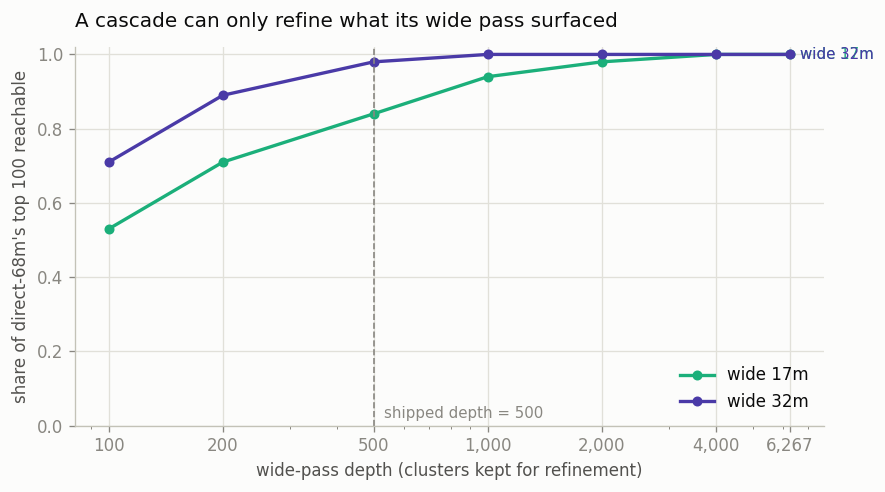

       direct-17m  direct-32m
depth                        
100          0.53        0.71
200          0.71        0.89
500          0.84        0.98
1,000        0.94        1.00
2,000        0.98        1.00
4,000        1.00        1.00
6,267        1.00        1.00


In [19]:
ref_keys = set(keys_at(REF))
depths = [100, 200, 500, 1000, 2000, 4000, len(POOL_PLUGIN)]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
curves = {}
for wide_name, colour_of in (("direct-17m", "cascade-17m-68m"), ("direct-32m", "cascade-32m-68m")):
    r = RANKED[wide_name].sort_values("cluster_rank")
    recalls = []
    for n in depths:
        seen = set(r.head(n)["cluster_key"])
        recalls.append(len(ref_keys & seen) / len(ref_keys))
    curves[wide_name] = recalls
    ax.plot(depths, recalls, marker="o", markersize=5, linewidth=2,
            color=COLOR[colour_of], label=wide_name.replace("direct-", "wide "))
    ax.annotate(wide_name.replace("direct-", "wide "), (depths[-1], recalls[-1]),
                textcoords="offset points", xytext=(6, 0), va="center",
                color=COLOR[colour_of], fontsize=9)

ax.axvline(REFINE_DEPTH, color=MUTED, linestyle="--", linewidth=1)
ax.annotate(f"shipped depth = {REFINE_DEPTH}", (REFINE_DEPTH, 0.02),
            textcoords="offset points", xytext=(6, 0), color=MUTED, fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("wide-pass depth (clusters kept for refinement)")
ax.set_ylabel(f"share of {REF}'s top {TOP_K} reachable")
ax.set_ylim(0, 1.02)
ax.set_title("A cascade can only refine what its wide pass surfaced", loc="left", pad=12)
ax.set_xticks(depths); ax.set_xticklabels([f"{d:,}" for d in depths], rotation=0)
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

DEPTH_TABLE = pd.DataFrame(curves, index=[f"{d:,}" for d in depths]).round(3)
DEPTH_TABLE.index.name = "depth"
DEPTH_TABLE.to_csv(RESULTS_DIR / "m1_depth_sweep.csv")
print(DEPTH_TABLE.to_string())

### M2 — How much of the expensive model's selection does each config recover?

`direct-68m` is the reference: the strongest model, reading every description, with
no cascade truncation to lose anything. For every other config, what share of its
top 100 does it recover?

Overlap is computed on **cluster keys, not job ids**. A config that picks a
different posting of the same requisition has not disagreed about anything, and
scoring that as a miss would be measuring the tie-break, not the ranking.

In [20]:
rows = []
for cfg in CONFIGS:
    n = cfg["name"]
    got = set(keys_at(n))
    rows.append({
        "key": cfg["key"], "config": n,
        "recall_vs_ref": len(got & ref_keys) / len(ref_keys),
        "rerank_s": SUMMARY.set_index("config").loc[n, "rerank_s"],
        "total_s": SUMMARY.set_index("config").loc[n, "total_s"],
    })
M2 = pd.DataFrame(rows).sort_values("recall_vs_ref", ascending=False)
M2.to_csv(RESULTS_DIR / "m2_recall_vs_reference.csv", index=False)
print(f"reference = {REF}\n")
print(M2.round(3).to_string(index=False))

reference = direct-68m

key            config  recall_vs_ref  rerank_s  total_s
  3        direct-68m           1.00  1008.079 1017.489
  6   cascade-32m-68m           0.95   443.665  453.076
  2   cascade-17m-68m           0.78   301.705  311.117
  4        direct-32m           0.71   365.773  375.182
  5   cascade-17m-32m           0.67   238.595  248.004
  7        direct-17m           0.53   203.026  212.438
 1b minilm-controlled           0.31     0.000    9.412
  1   original-minilm           0.24     0.000    9.371


### M3 — Cost versus agreement

The ship decision reads straight off this. Anything up and to the left dominates.

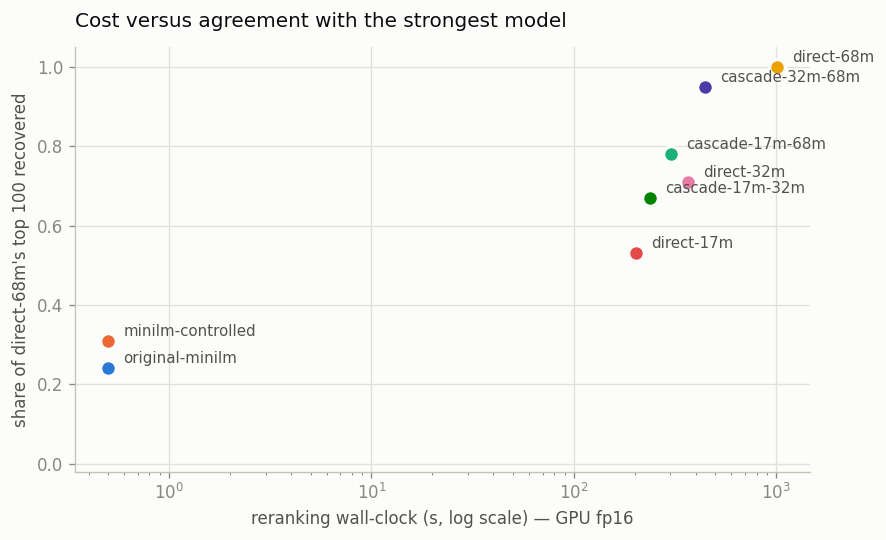

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for _, r in M2.iterrows():
    x = max(r["rerank_s"], 0.5)
    ax.scatter(x, r["recall_vs_ref"], s=90, color=COLOR[r["config"]],
               zorder=3, edgecolor=SURFACE, linewidth=2)
    ax.annotate(r["config"], (x, r["recall_vs_ref"]), textcoords="offset points",
                xytext=(9, 3), fontsize=9, color="#52514e")
ax.set_xscale("log")
ax.set_xlabel("reranking wall-clock (s, log scale) — GPU fp16")
ax.set_ylabel(f"share of {REF}'s top {TOP_K} recovered")
ax.set_title("Cost versus agreement with the strongest model", loc="left", pad=12)
ax.set_ylim(-0.02, 1.05)
plt.tight_layout(); plt.show()

### M4 — Pairwise agreement

Two panels. **Jaccard@100** on cluster keys is the blunt "do these pick the same
jobs" number. **RBO** (rank-biased overlap, p=0.98) compares the full ordered lists
but weights the top, which is the only part anyone looks at — Spearman over 6,000
items would be dominated by a tail nobody will ever read and would report ~0.9 for
two configs that disagree completely about the top 100.

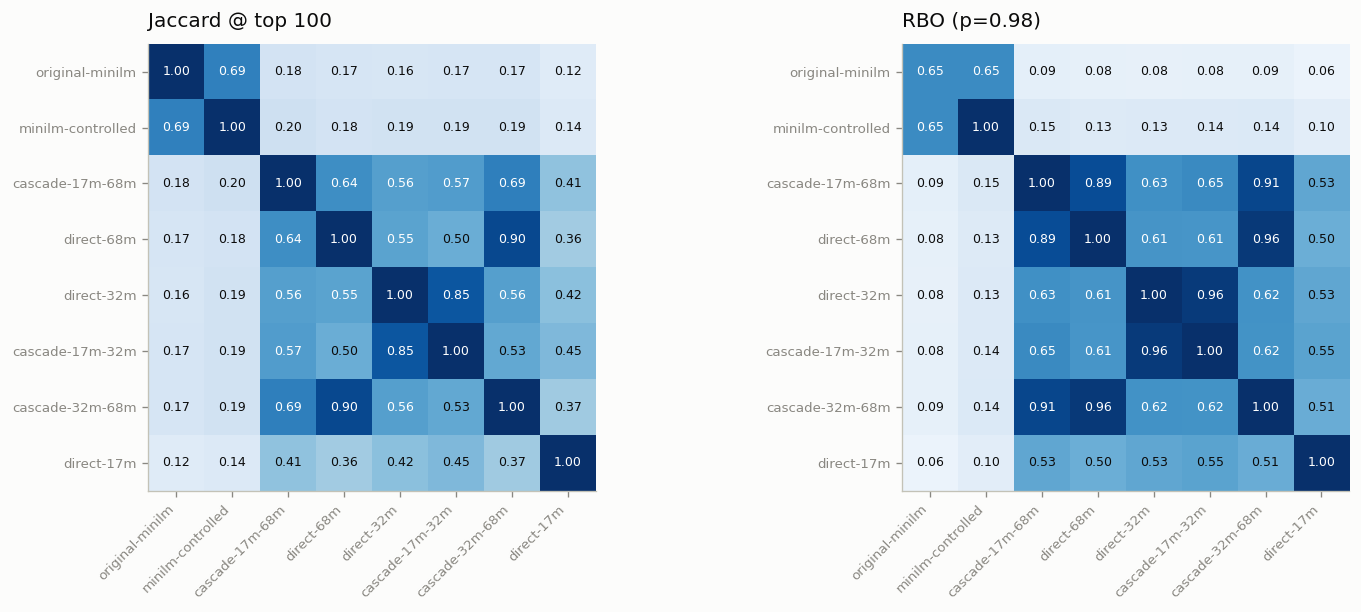

In [22]:
def rbo(a: list, b: list, p: float = 0.98) -> float:
    sa, sb, total = set(), set(), 0.0
    for d in range(1, max(len(a), len(b)) + 1):
        if d <= len(a): sa.add(a[d - 1])
        if d <= len(b): sb.add(b[d - 1])
        total += (p ** (d - 1)) * len(sa & sb) / d
    return (1 - p) * total

names = [c["name"] for c in CONFIGS]
top = {n: keys_at(n) for n in names}
full = {n: list(RANKED[n].sort_values("cluster_rank")["cluster_key"]) for n in names}

J = pd.DataFrame(index=names, columns=names, dtype=float)
R = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        sa, sb = set(top[a]), set(top[b])
        J.loc[a, b] = len(sa & sb) / len(sa | sb)
        R.loc[a, b] = rbo(full[a], full[b])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, M, title in ((axes[0], J, f"Jaccard @ top {TOP_K}"), (axes[1], R, "RBO (p=0.98)")):
    im = ax.imshow(M.values.astype(float), cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
    ax.set_title(title, loc="left", pad=10); ax.grid(False)
    for i in range(len(names)):
        for j in range(len(names)):
            v = float(M.values[i, j])
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                    color="#ffffff" if v > 0.55 else INK)
plt.tight_layout(); plt.show()

J.round(3).to_csv(RESULTS_DIR / "m4_jaccard_top100.csv")
R.round(3).to_csv(RESULTS_DIR / "m4_rbo.csv")

### M5 — Selection health

Agreement says nothing about whether a selection is *sane*. Three specific failure
modes are worth checking by name:

- **one employer eating the budget** — the reason `cluster.py` exists at all,
  after a single requisition took 31 of 100 slots;
- **length bias**, a known cross-encoder failure where the model learns to prefer
  long documents. `corr(score, desc_chars)` catches it;
- **a reranker that is worse than the gate it replaces** — if a config's top 100
  has a *lower* mean title cosine than MiniLM's own selection, something is wrong.

In [23]:
rows = []
for cfg in CONFIGS:
    n = cfg["name"]
    s = SELECTED[n]
    r = RANKED[n]
    joined = r.merge(
        pd.DataFrame([{"job_id": j.job_id, "desc_chars": len(j.content_text or "")}
                      for j in (POOL_ORIGINAL if cfg["gate"] == GATE_ORIGINAL else POOL_PLUGIN)]),
        on="job_id", how="left")
    rows.append({
        "key": cfg["key"], "config": n,
        "companies": s["board_token"].nunique(),
        "max_from_one_company": s["board_token"].value_counts().max(),
        "mean_cluster_size": s["cluster_size"].mean(),
        "max_cluster_size": s["cluster_size"].max(),
        "mean_title_cosine": s["encoder_score"].mean(),
        "mean_desc_chars": s["desc_chars"].mean(),
        "corr_score_vs_len": joined["rank_score"].corr(joined["desc_chars"]),
    })
M5 = pd.DataFrame(rows)
M5.to_csv(RESULTS_DIR / "m5_selection_health.csv", index=False)
print(M5.round(3).to_string(index=False))

key            config  companies  max_from_one_company  mean_cluster_size  max_cluster_size  mean_title_cosine  mean_desc_chars  corr_score_vs_len
  1   original-minilm         56                    23               1.00                 1              0.975          6691.40              0.112
 1b minilm-controlled         75                    15               1.61                18              0.929          6509.80              0.126
  2   cascade-17m-68m         57                    14               1.54                18              0.721          5934.86              0.306
  3        direct-68m         53                    18               1.56                18              0.689          5556.93              0.173
  4        direct-32m         44                    19               1.63                18              0.713          5978.15              0.155
  5   cascade-17m-32m         43                    22               1.58                18              0.710        

In [24]:
# The union of every config's top 20, with an empty verdict column. There is no
# label in this dataset; this file is the cheapest path to one.
frames = []
for cfg in CONFIGS:
    s = SELECTED[cfg["name"]].head(20)[["job_id", "board_token", "title", "location", "url"]].copy()
    s["config"] = cfg["name"]
    frames.append(s)
u = pd.concat(frames)
agg = (u.groupby(["job_id", "board_token", "title", "location", "url"])
         .agg(n_configs=("config", "nunique"), configs=("config", lambda x: ";".join(sorted(set(x)))))
         .reset_index().sort_values(["n_configs", "board_token"], ascending=[False, True]))
agg["verdict"] = ""
agg.to_csv(RESULTS_DIR / "human_review.csv", index=False)
print(f"{len(agg)} distinct jobs across the eight top-20s -> results/human_review.csv")
print(agg.head(25)[["n_configs", "board_token", "title", "configs"]].to_string(index=False))

66 distinct jobs across the eight top-20s -> results/human_review.csv
 n_configs                   board_token                                                     title                                                                          configs
         6 bpinternational|wd3|bpcareers                                         Software engineer cascade-17m-32m;cascade-17m-68m;cascade-32m-68m;direct-17m;direct-32m;direct-68m
         6    dentsuaegis|wd3|dan_global                                        Data & AI Engineer cascade-17m-32m;cascade-17m-68m;cascade-32m-68m;direct-17m;direct-32m;direct-68m
         6   globalhealthcareexchangeinc                                     Software Engineer III cascade-17m-32m;cascade-17m-68m;cascade-32m-68m;direct-17m;direct-32m;direct-68m
         6     maersk|wd3|maersk_careers                               Software Engineer - Dot Net cascade-17m-32m;cascade-17m-68m;cascade-32m-68m;direct-17m;direct-32m;direct-68m
         6                    

### Score distributions

Kept, but read with care. **These are different models' logits and the scales are
not comparable** — `RerankScores` puts it plainly: *"`wide` and `refined` come from
DIFFERENT MODELS and are therefore on different logit scales. Comparing or averaging
them is meaningless, and sorting a mixed list of them silently produces a wrong
ranking."* The panels below are for shape — spread, separation, degenerate
flatness — never for cross-model comparison of absolute values.

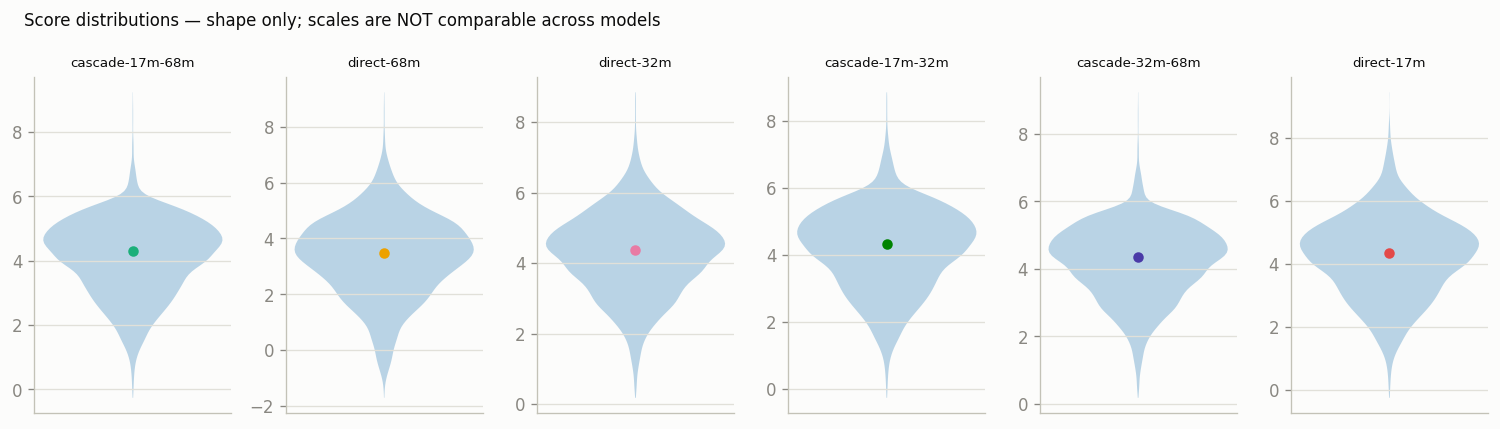

In [25]:
cross = [c for c in CONFIGS if c["wide"]]
fig, axes = plt.subplots(1, len(cross), figsize=(2.1 * len(cross), 3.6), sharey=False)
for ax, cfg in zip(np.atleast_1d(axes), cross):
    v = RANKED[cfg["name"]]["rank_score"].values
    ax.violinplot(v, showextrema=False, widths=0.85)
    ax.scatter([1], [np.median(v)], color=COLOR[cfg["name"]], s=28, zorder=3)
    ax.set_title(cfg["name"], fontsize=8, loc="center")
    ax.set_xticks([]); ax.grid(axis="x", visible=False)
fig.suptitle("Score distributions — shape only; scales are NOT comparable across models",
             fontsize=10, x=0.02, ha="left")
plt.tight_layout(); plt.show()

## 8. Verdict

In [26]:
best_value = M2[M2["config"] != REF].sort_values(
    ["recall_vs_ref", "rerank_s"], ascending=[False, True]).iloc[0]
shipped = M2[M2["config"] == "cascade-17m-68m"].iloc[0]
ref_row = M2[M2["config"] == REF].iloc[0]
baseline = M2[M2["config"] == "minilm-controlled"].iloc[0]
d500 = DEPTH_TABLE.loc[f"{REFINE_DEPTH:,}", "direct-17m"]

print(f"""
Reference                 {REF}: {ref_row['rerank_s']:.0f}s of reranking
Shipped config            cascade-17m-68m: {shipped['recall_vs_ref']:.0%} of the
                          reference's top {TOP_K}, in {shipped['rerank_s']:.0f}s
                          ({ref_row['rerank_s'] / max(shipped['rerank_s'], 1e-9):.1f}x cheaper)
Is the cross-encoder
earning its keep?         the controlled MiniLM baseline recovers
                          {baseline['recall_vs_ref']:.0%} of the same selection
Is depth={REFINE_DEPTH} enough?     17m's top {REFINE_DEPTH} contains {d500:.0%} of what
                          {REF} would pick
Best cost/agreement       {best_value['config']} at {best_value['recall_vs_ref']:.0%}
                          for {best_value['rerank_s']:.0f}s
""")
print("Full artifacts in", RESULTS_DIR)
for p in sorted(RESULTS_DIR.glob("*.csv")):
    print("  ", p.name)


Reference                 direct-68m: 1008s of reranking
Shipped config            cascade-17m-68m: 78% of the
                          reference's top 100, in 302s
                          (3.3x cheaper)
Is the cross-encoder
earning its keep?         the controlled MiniLM baseline recovers
                          31% of the same selection
Is depth=500 enough?     17m's top 500 contains 84% of what
                          direct-68m would pick
Best cost/agreement       cascade-32m-68m at 95%
                          for 444s

Full artifacts in D:\Atreya\College\Projects\HireShire-plugin\analysis\results
   human_review.csv
   m1_depth_sweep.csv
   m2_recall_vs_reference.csv
   m4_jaccard_top100.csv
   m4_rbo.csv
   m5_selection_health.csv
   ranked__cascade-17m-32m.csv
   ranked__cascade-17m-68m.csv
   ranked__cascade-32m-68m.csv
   ranked__direct-17m.csv
   ranked__direct-32m.csv
   ranked__direct-68m.csv
   ranked__minilm-controlled.csv
   ranked__original-minilm.csv
   selec

### What this run found

Numbers below are from the full run: pool of 6,267 jobs, 4,558 clusters, `top_k=100`,
GPU fp16.

**1. The shipped config's bottleneck is its wide model, not its refine model.**
`cascade-17m-68m` recovers **78%** of what `direct-68m` selects. The depth sweep
explains exactly why: the 17m wide pass's top 500 contains only **84%** of
`direct-68m`'s top 100. Roughly one in six of the best jobs is discarded *before the
68m model ever reads it*, and no improvement to the refine stage can recover them —
`refine.depth: 500` is a binding constraint, not a comfortable margin. It is visible
in the individual rows too: jobs at wide rank 101, 234 and 238 are pulled into the
final top 15 by the refiner, which is precisely the behaviour that implies more good
jobs are sitting just past the cut.

**2. Promoting 32m to the wide stage is the cheap fix.** The 32m model's top 500
contains **98%** of the reference's top 100, versus 84% for 17m. `cascade-32m-68m`
therefore reaches **95%** recall for **444 s**, against 1,008 s for `direct-68m` —
the same selection, near enough, at 2.3× less compute. Against the shipped config
that is +17 points of recall for +142 s. Its Jaccard against `direct-68m` is 0.90,
by far the highest of any config. Raising the 17m cascade's depth is the alternative
(94% reachable at depth 1,000, costing roughly 400 s) but it buys a lower ceiling for
about the same money.

**3. The cross-encoder is emphatically earning its keep.** The controlled MiniLM
baseline — same pool, same clustering, ranked by title cosine — recovers only **31%**
of the reference selection. Whatever else is true, roughly seven of every ten jobs
sent to the LLM are there because of the reranker.

**4. `direct-17m` is not a viable shortcut, and the reason is a health metric rather
than an agreement one.** It puts **44 of its 100 slots into a single employer**
(`accenturefederalservices`), against 14–19 for every other cross-encoder config. It
also shows the strongest length bias in the set (`corr(score, desc_chars) = 0.33`
versus 0.17 for 68m). A model that concentrates half the budget on one company and
prefers long documents is doing something other than judging fit.

**5. Clustering is load-bearing.** 6,267 postings collapse to 4,558 clusters; the
largest holds 18 copies; the top 100 slots cover 154 actual postings. Without it, the
budget arithmetic in every row above would be materially different.

**Recommendation.** Change `funnel.rerank.model` from `ettin-reranker-17m-v1` to
`ettin-reranker-32m-v1`, keeping `refine.model` at 68m and `depth` at 500. On this
run that moves recall of the strongest model's selection from 78% to 95% for a 47%
increase in reranking time — and the plugin's CPU-bound cost profile differs from
this GPU measurement, so the wall-clock trade should be re-measured on the target
hardware before shipping. Treat this as one run against one persona, and see the
caveats below.

### Reading this honestly

Three caveats belong next to any conclusion drawn above.

**Agreement is not accuracy.** `direct-68m` is the reference because it is the
strongest and least-truncated configuration available, not because it is known to be
right. A config that agrees with it 90% of the time is 90% as good *only if the
reference is good*. `results/human_review.csv` exists to break that circularity:
marking the ~60–150 rows in it turns every number here into a real precision@20.

**These seconds are GPU fp16.** Production runs fp32 on CPU, where `CHANGELOG.md`
measured stage 1 at ~32 minutes for a 7,021-job sweep. The absolute numbers here are
a cost *model*, not a production latency. They are measured consistently across
configs, which is what the comparison needs — but do not quote them as sweep times.

**One run, one persona.** Everything above is a single sweep judged against a single
search profile. A config that wins here has won once.